In [14]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw

In [2]:
df = pd.read_csv('data/receptor_std.csv')

In [3]:
df.head(2)

,molecule_chembl_id,canonical_smiles,pKi,active,std_smiles
0,CHEMBL542123,Br.C=CCN(C)CC[C@@]12CCCC[C@@H]1C=Cc1ccc(OC)cc12,7.309804,1,C=CCN(C)CC[C@@]12CCCC[C@@H]1C=Cc1ccc(OC)cc12
1,CHEMBL542217,Br.CC(C1CC1)N1CCC(C2CCc3ccccc3C2=O)CC1,7.585027,1,CC(C1CC1)N1CCC(C2CCc3ccccc3C2=O)CC1


In [7]:
def get_scaffold(smiles):        
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
        
    return None

In [8]:
df['scaffold'] = df['std_smiles'].apply(get_scaffold)

In [12]:
print("Number of unique scaffolds:", df['scaffold'].nunique())
common_scaffolds = set(df[df['active'] == 1]['scaffold']).intersection(set(df[df['active'] == 0]['scaffold']))
print("Number of common scaffolds:", len(common_scaffolds))

Number of unique scaffolds: 1382
Number of common scaffolds: 80


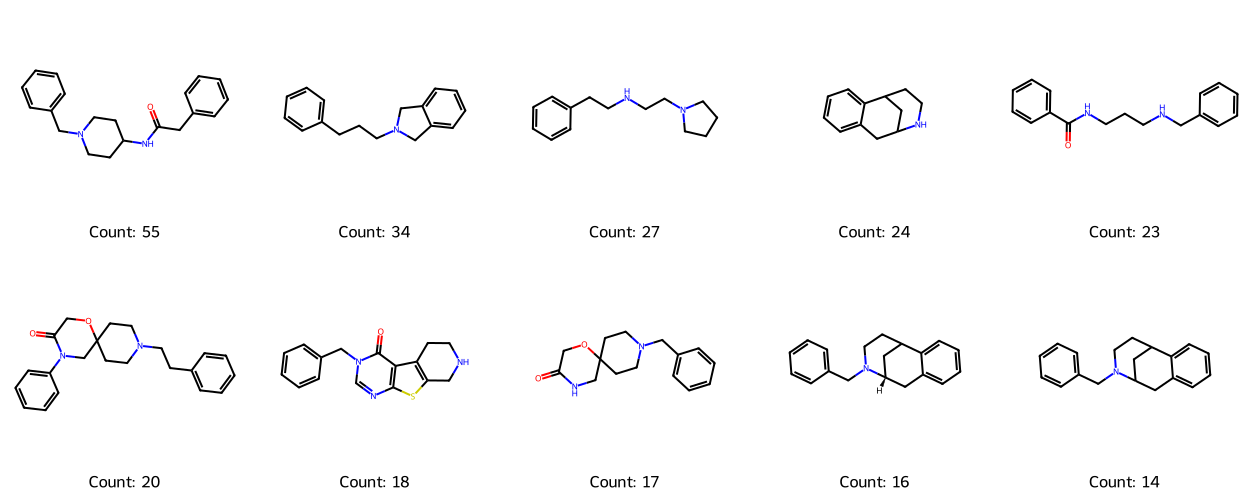

In [16]:
top_scaffolds_active = df[df['active'] == 1]['scaffold'].value_counts().head(10)
mols_active = [Chem.MolFromSmiles(smiles) for smiles in top_scaffolds_active.index]
legends = [f"Count: {count}" for count in top_scaffolds_active.values]

Draw.MolsToGridImage(
    mols_active, 
    molsPerRow=5,
    subImgSize=(250, 250),
    legends=legends
)

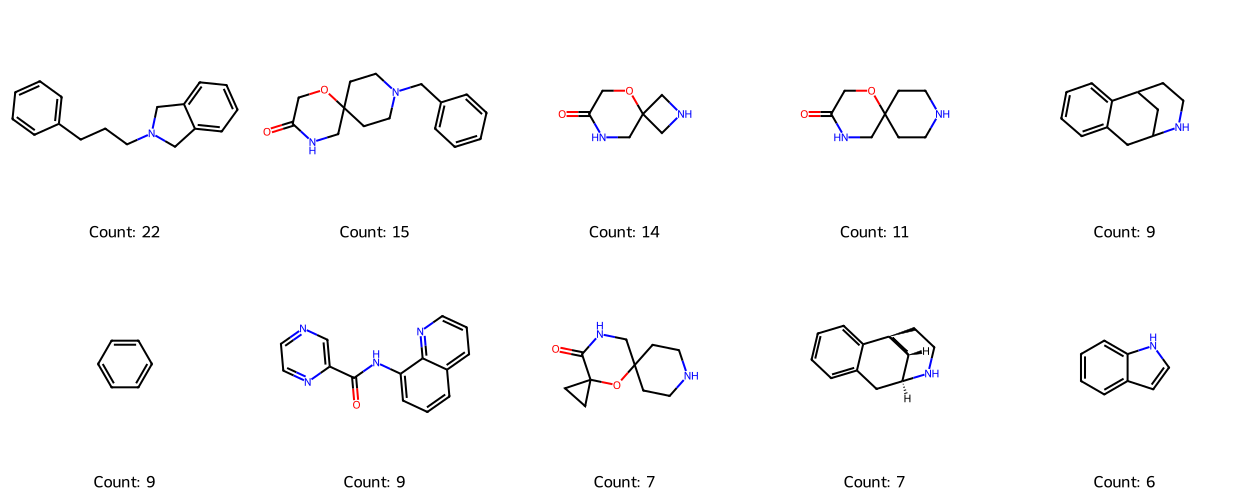

In [17]:
top_scaffolds_inactive = df[df['active'] == 0]['scaffold'].value_counts().head(10)
mols_inactive = [Chem.MolFromSmiles(smiles) for smiles in top_scaffolds_inactive.index]
legends = [f"Count: {count}" for count in top_scaffolds_inactive.values]

Draw.MolsToGridImage(
    mols_inactive, 
    molsPerRow=5,
    subImgSize=(250, 250),
    legends=legends
)